# Segment Creator and Analyser

In [1]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
!{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

!mkdir images
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg

!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA is available: True
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-w0ezumrr
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-w0ezumrr
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=548e98893185f1e2bb8aab629c233bcd79b8c5b88c1fbdf9316825b10bf5871f
  Stored in directory: /tmp/pip-ephem-wheel-cache-s2qqsqd5/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything
--2026-04-21 17:49:32--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.co

In [2]:
import matplotlib.pyplot as plt
import cv2
from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np

In [3]:
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)

In [4]:
def get_mask(input_path):

  image = cv2.imread(input_path)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  plt.imshow(image)
  plt.show()

  plt.figure()

  masks = mask_generator.generate(image)

  fig = plt.figure(figsize=(20., 20.))
  grid = ImageGrid(fig, 111,
                  nrows_ncols=(int((len(masks)+9)/10), 10),
                  axes_pad=0.1,
                  )

  l = []
  for i in range(len(masks)):
    l.append(masks[i]['segmentation'])

  for ax, im in zip(grid, l):
      ax.imshow(im)

  return masks

In [5]:
def compute_core_spurious(mask_nb, heatmap_paths, masks):
    for i, heatmap in enumerate(heatmap_paths):
      K = torch.tensor(masks[mask_nb]['segmentation'])
      img = cv2.imread(heatmap, cv2.IMREAD_GRAYSCALE)
      img = (img - img.min()) / (img.max() - img.min())
      core_mean = img[K].mean()
      K = ~K
      spurious_mean = img[K].mean()
      print('Core %     description_{}:'.format(i), core_mean/(core_mean+spurious_mean))
      print('Spurious % description_{}:'.format(i), spurious_mean/(core_mean+spurious_mean))

This is where changes need to happen by changing this path it gets all associated images from the folder required

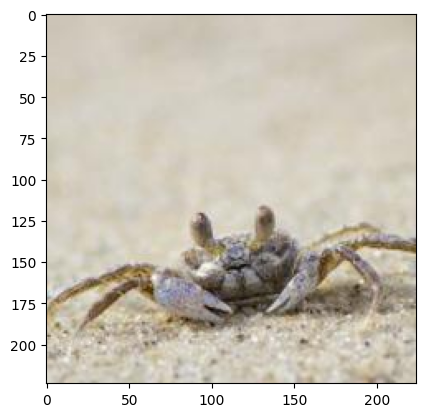

<Figure size 640x480 with 0 Axes>

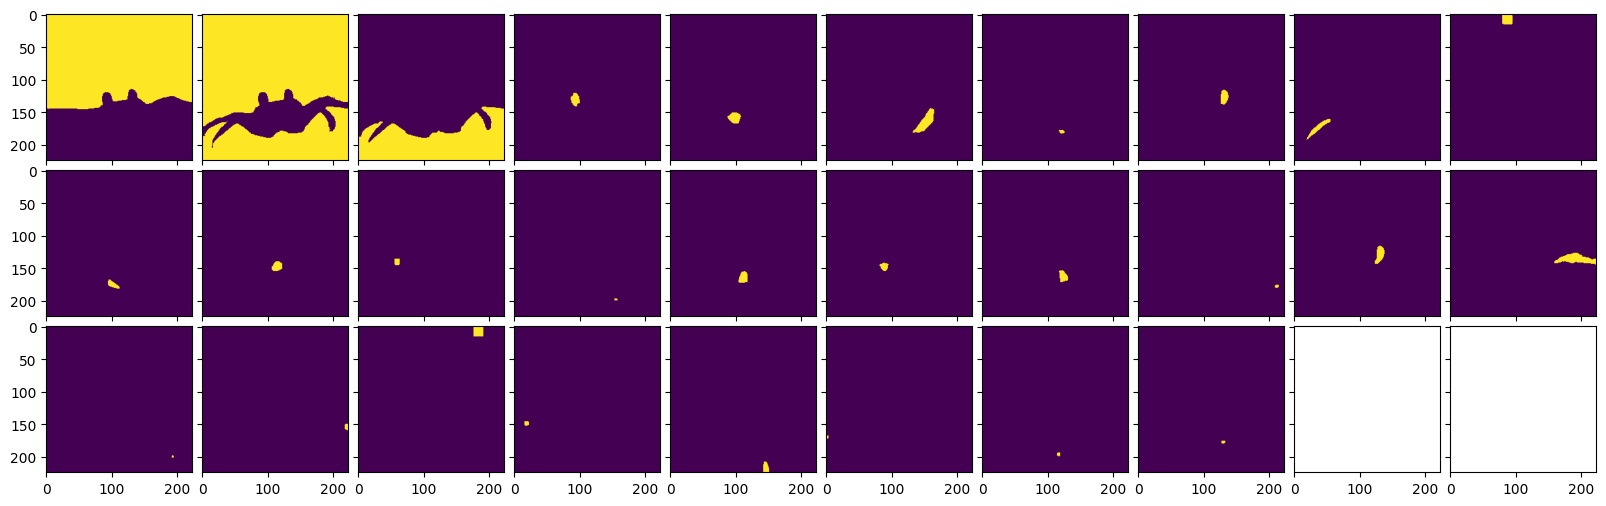

In [7]:
input_path = '/content/dissertation_perceptionCLIP/visualizations/results/crab/crab_input.jpg'
save_masks = get_mask(input_path)

In [8]:
mask_nb = 0
total_gradcams = 2
list_of_gradcams = []
for i in range(total_gradcams):
  list_of_gradcams.append('/'.join(input_path.split('/')[:-1]) + '/' + 'g_' + '_'.join(input_path.split('/')[-1].split('_')[:-1]) + '_gradcam_desc_{}.jpg'.format(i))
compute_core_spurious(mask_nb, list_of_gradcams, save_masks)

Core %     description_0: 0.2569055822906981
Spurious % description_0: 0.743094417709302
Core %     description_1: 0.1797326806301201
Spurious % description_1: 0.8202673193698798
